# A first look at the data

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
prices = pd.read_csv("../data/raw/prices_IT_2015_2024.csv", index_col=0, parse_dates=True)

In [3]:
prices.describe()

,0
count,78784.000000
mean,95.618858
std,98.919137
min,0.000000
25%,43.470000
50%,57.550000
75%,103.000000
max,871.000000


In [4]:
prices.isna().sum()

0    0
dtype: int64

In [5]:
prices.index = pd.to_datetime(prices.index, utc=True)
print(type(prices.index))

<class 'pandas.DatetimeIndex'>


In [6]:
print(f"Period: {prices.index.min()} -> {prices.index.max()}")

Period: 2015-01-04 23:00:00+00:00 -> 2023-12-31 23:00:00+00:00


In [7]:
(prices.index.max()-prices.index.min()).days*24 - prices.count() + 1

0    9
dtype: int64

There are 9 missing timestamps! Let's look at these.

In [8]:
full_range = pd.date_range(start=prices.index.min(), end=prices.index.max(), freq='h')
full_range.difference(prices.index)

DatetimeIndex(['2015-12-30 23:00:00+00:00', '2016-12-30 23:00:00+00:00',
               '2017-12-30 23:00:00+00:00', '2018-12-30 23:00:00+00:00',
               '2019-12-30 23:00:00+00:00', '2020-12-30 23:00:00+00:00',
               '2021-12-30 23:00:00+00:00', '2022-12-30 23:00:00+00:00',
               '2023-12-30 23:00:00+00:00'],
              dtype='datetime64[us, UTC]', freq=None)

For now, let's add these timestamps with NaN value and overwrite the original csv file

In [12]:
prices = prices.reindex(full_range)
prices.ffill(inplace=True)
prices.loc[pd.isna(prices['0'])].index
prices.to_csv('../data/raw/prices_IT_2015_2024.csv')

In [10]:
print(prices[prices['0']<=0].count())
print(prices[prices['0']<=10].count())

0    5
dtype: int64
0    228
dtype: int64


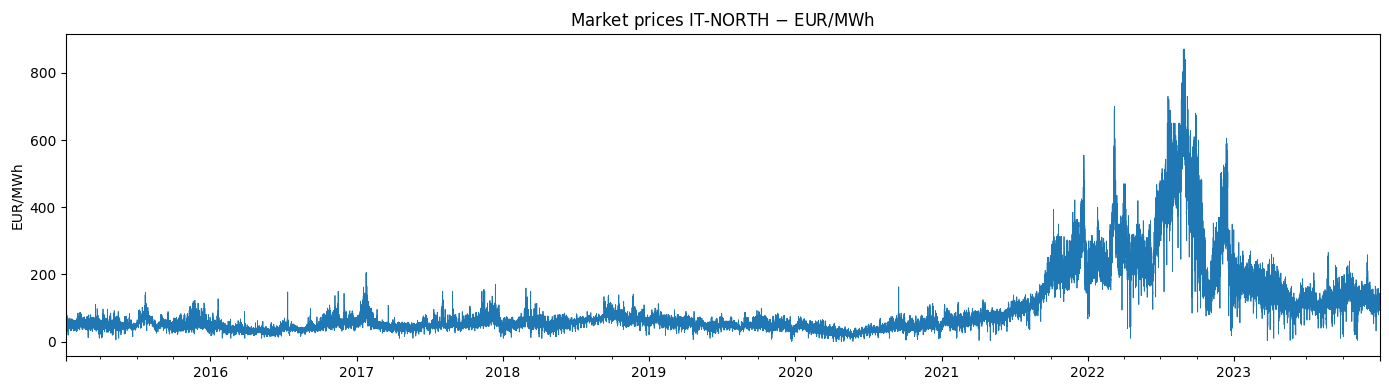

In [11]:
fig, ax = plt.subplots(figsize=(14, 4))
prices.plot(ax=ax, linewidth=0.6, color="C0", legend=False)
ax.set_title("Market prices IT-NORTH $-$ EUR/MWh")
ax.set_ylabel("EUR/MWh")
# ax.tick_params(axis='x', labelrotation=10)
plt.tight_layout()
plt.savefig("../data/processed/01_market_prices.png", dpi=150)

In this notebook I carried out a simple description of the dataset. There are no "holes" in the time series, but in 54 istances the price is zero and 716 times it is below 10 EUR/MWh, which is credible. This dataset includes data from the Covid lockdown and from the global gas crysis. Such outliers will be significative to avoid overfitting on standard behaviour.